# Random Forest

In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, recall_score, f1_score, precision_score)

#### 1. Exploratory Data Analysis (EDA):

In [5]:
df = pd.read_excel("glass.xlsx", sheet_name = 1)
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [10]:
df.shape

(214, 10)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [8]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [11]:
df.columns

Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type'], dtype='object')

In [13]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [14]:
df = df.dropna()

In [15]:
df.duplicated().sum()

np.int64(1)

In [16]:
df.drop_duplicates(inplace = True)

In [17]:
for col in df.columns:
    print(col, df[col].unique())

RI [1.52101 1.51761 1.51618 1.51766 1.51742 1.51596 1.51743 1.51756 1.51918
 1.51755 1.51571 1.51763 1.51589 1.51748 1.51784 1.52196 1.51911 1.51735
 1.5175  1.51966 1.51736 1.51751 1.5172  1.51764 1.51793 1.51721 1.51768
 1.51747 1.51775 1.51753 1.51783 1.51567 1.51909 1.51797 1.52213 1.51779
 1.5221  1.51786 1.519   1.51869 1.52667 1.52223 1.51898 1.5232  1.51926
 1.51808 1.51837 1.51778 1.51769 1.51215 1.51824 1.51754 1.51905 1.51977
 1.52172 1.52227 1.52099 1.52152 1.523   1.51574 1.51848 1.51593 1.51631
 1.5159  1.51645 1.51627 1.51613 1.51592 1.51646 1.51594 1.51409 1.51625
 1.51569 1.5164  1.51841 1.51605 1.51588 1.51629 1.5186  1.51689 1.51811
 1.51655 1.5173  1.5182  1.52725 1.5241  1.52475 1.53125 1.53393 1.52222
 1.51818 1.52664 1.52739 1.52777 1.51892 1.51847 1.51846 1.51829 1.51708
 1.51673 1.51652 1.51844 1.51663 1.51687 1.51707 1.52177 1.51872 1.51667
 1.52081 1.52068 1.5202  1.52614 1.51813 1.518   1.51789 1.51806 1.51711
 1.51674 1.5169  1.51851 1.51662 1.51709 1.5166 

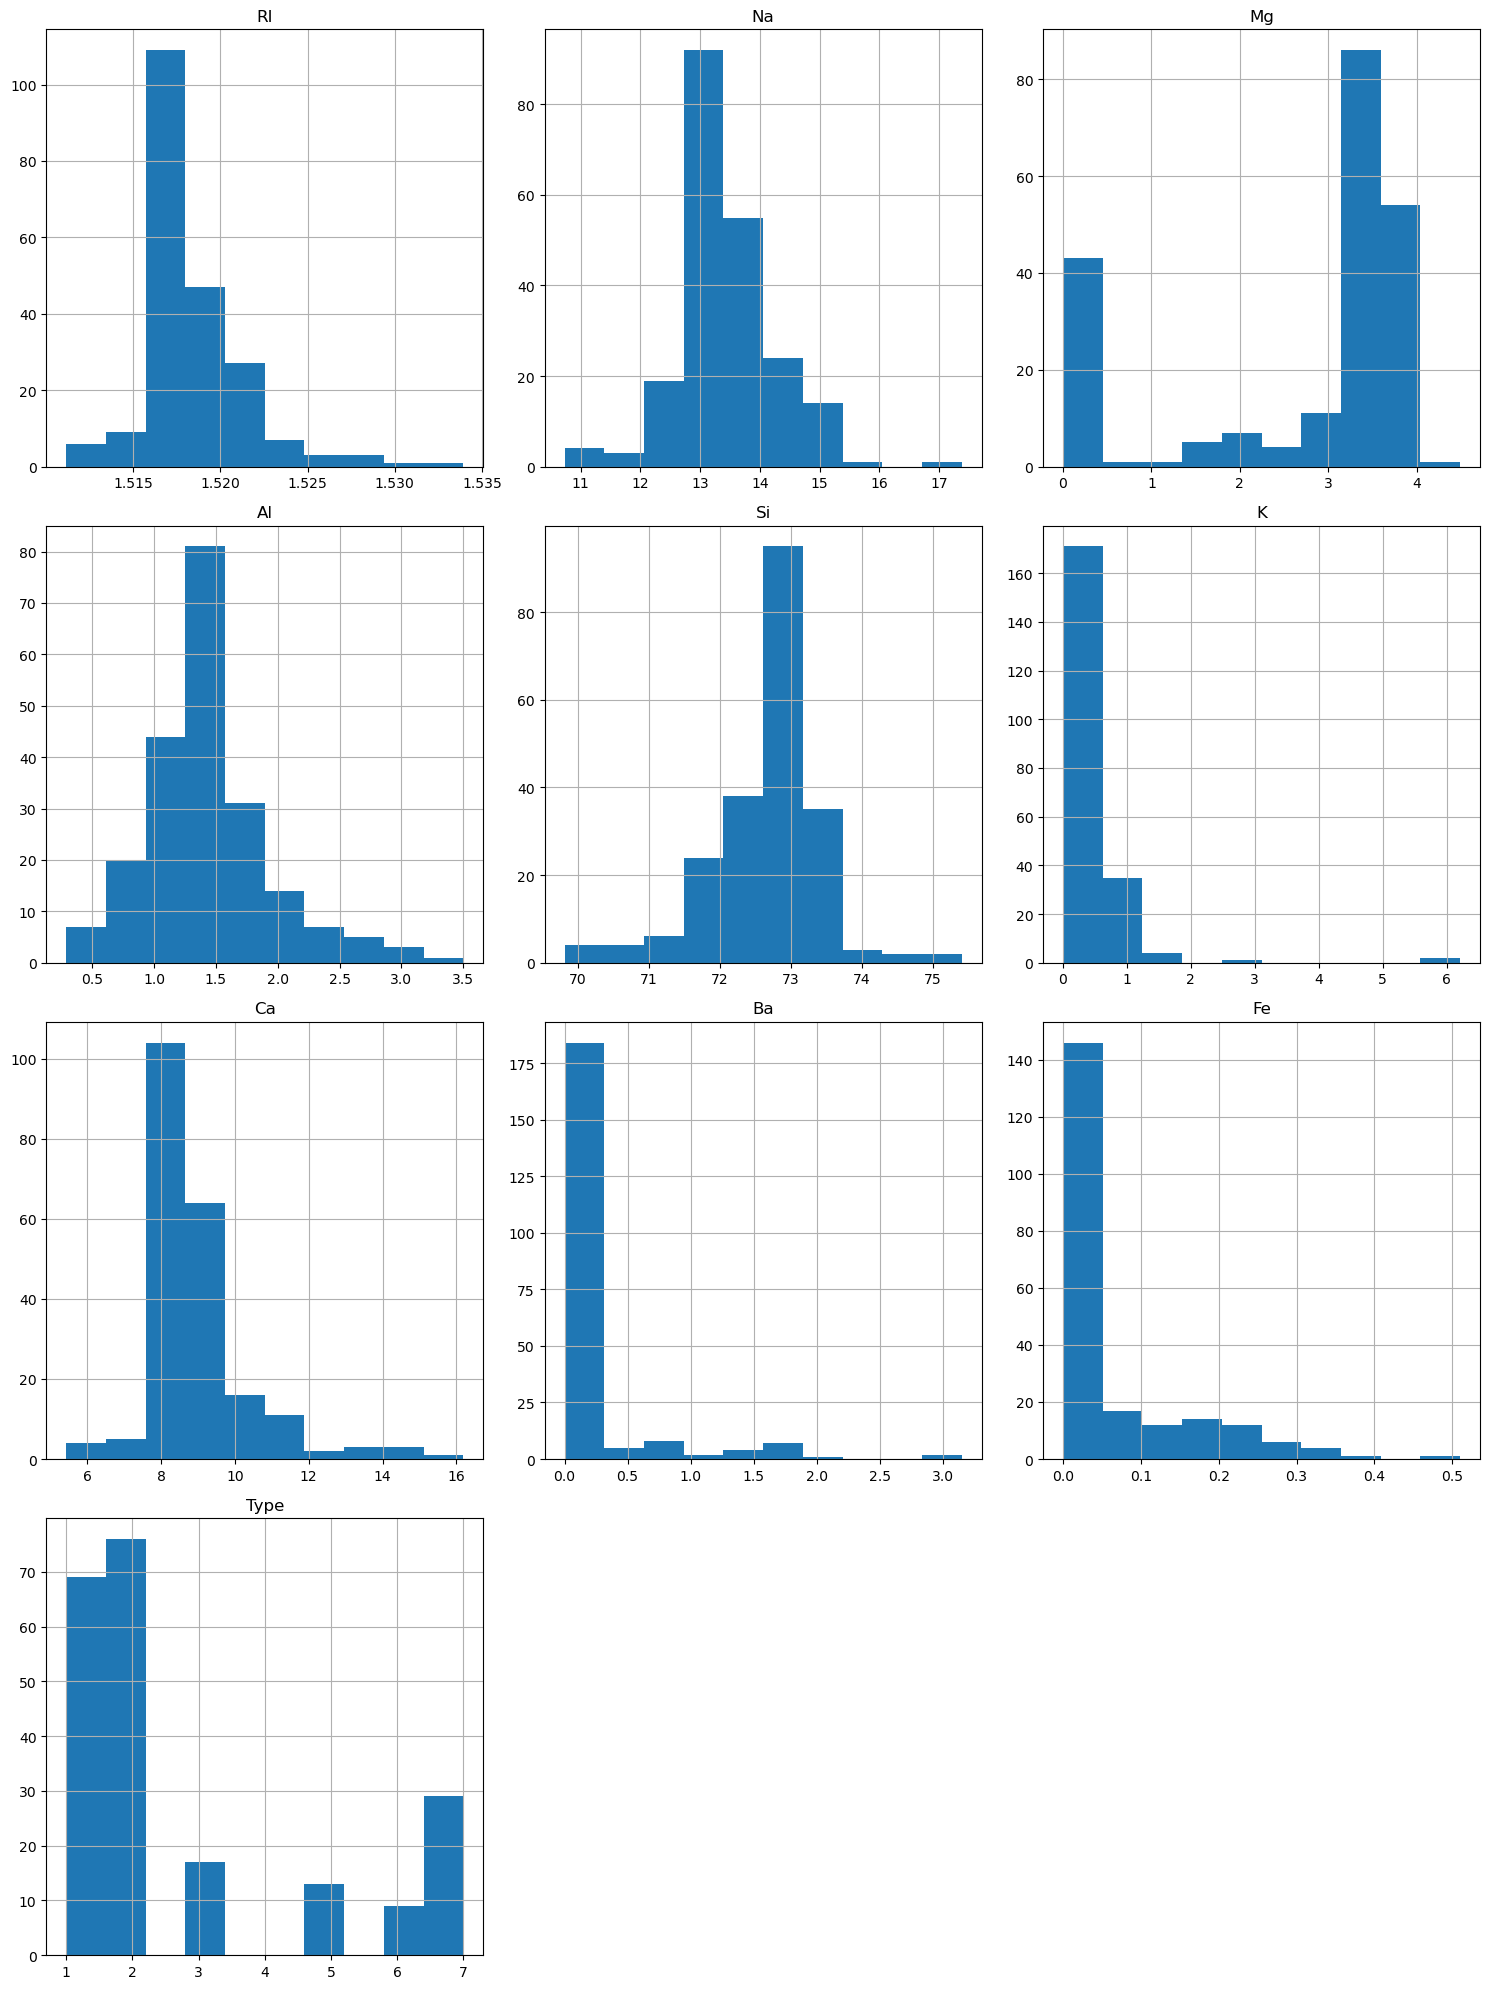

In [20]:
df.hist(figsize = (15,20))
plt.tight_layout()
plt.show()

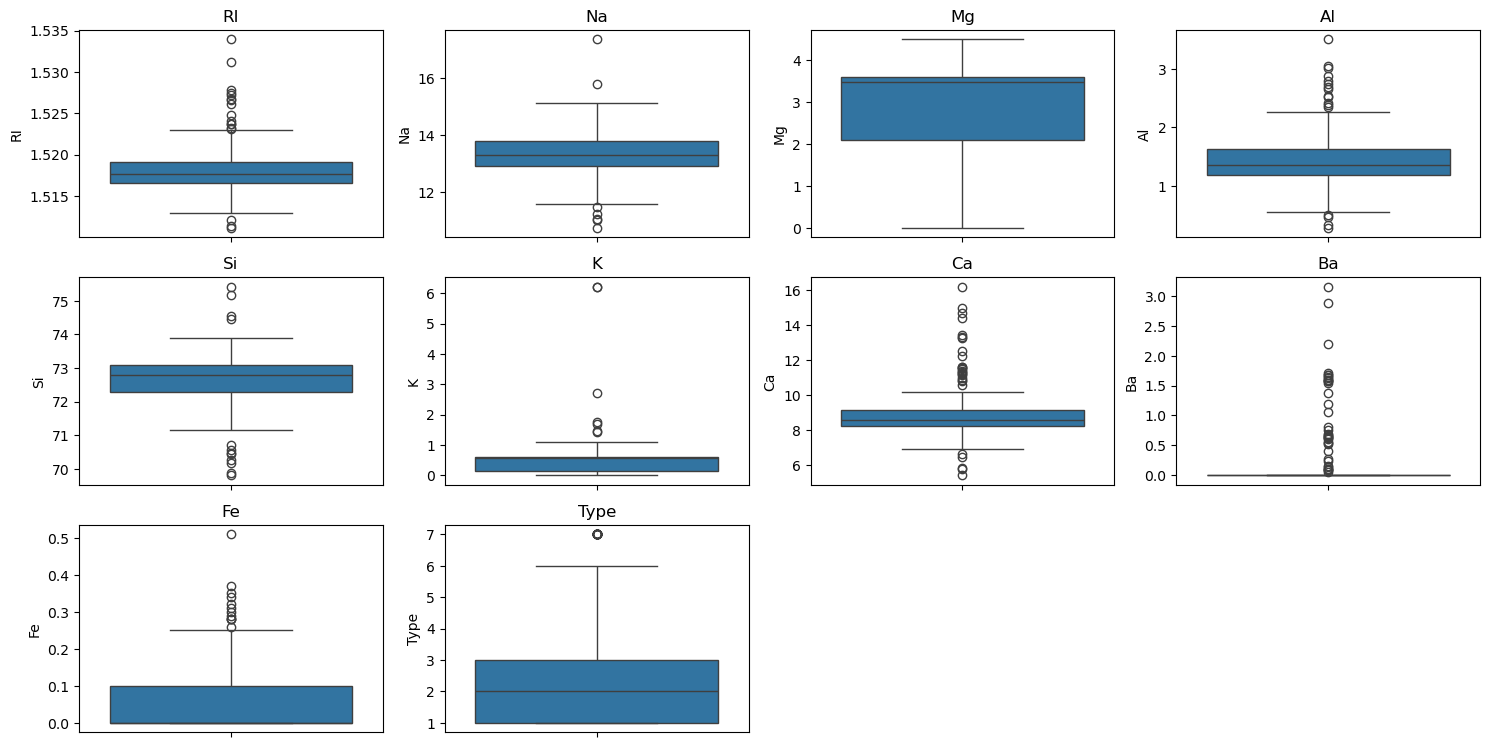

In [21]:
plt.figure(figsize=(15, 10))
numeric_cols = df.select_dtypes(include=np.number).columns
for i, col in enumerate(numeric_cols):
    plt.subplot(4,4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

## Pairplot

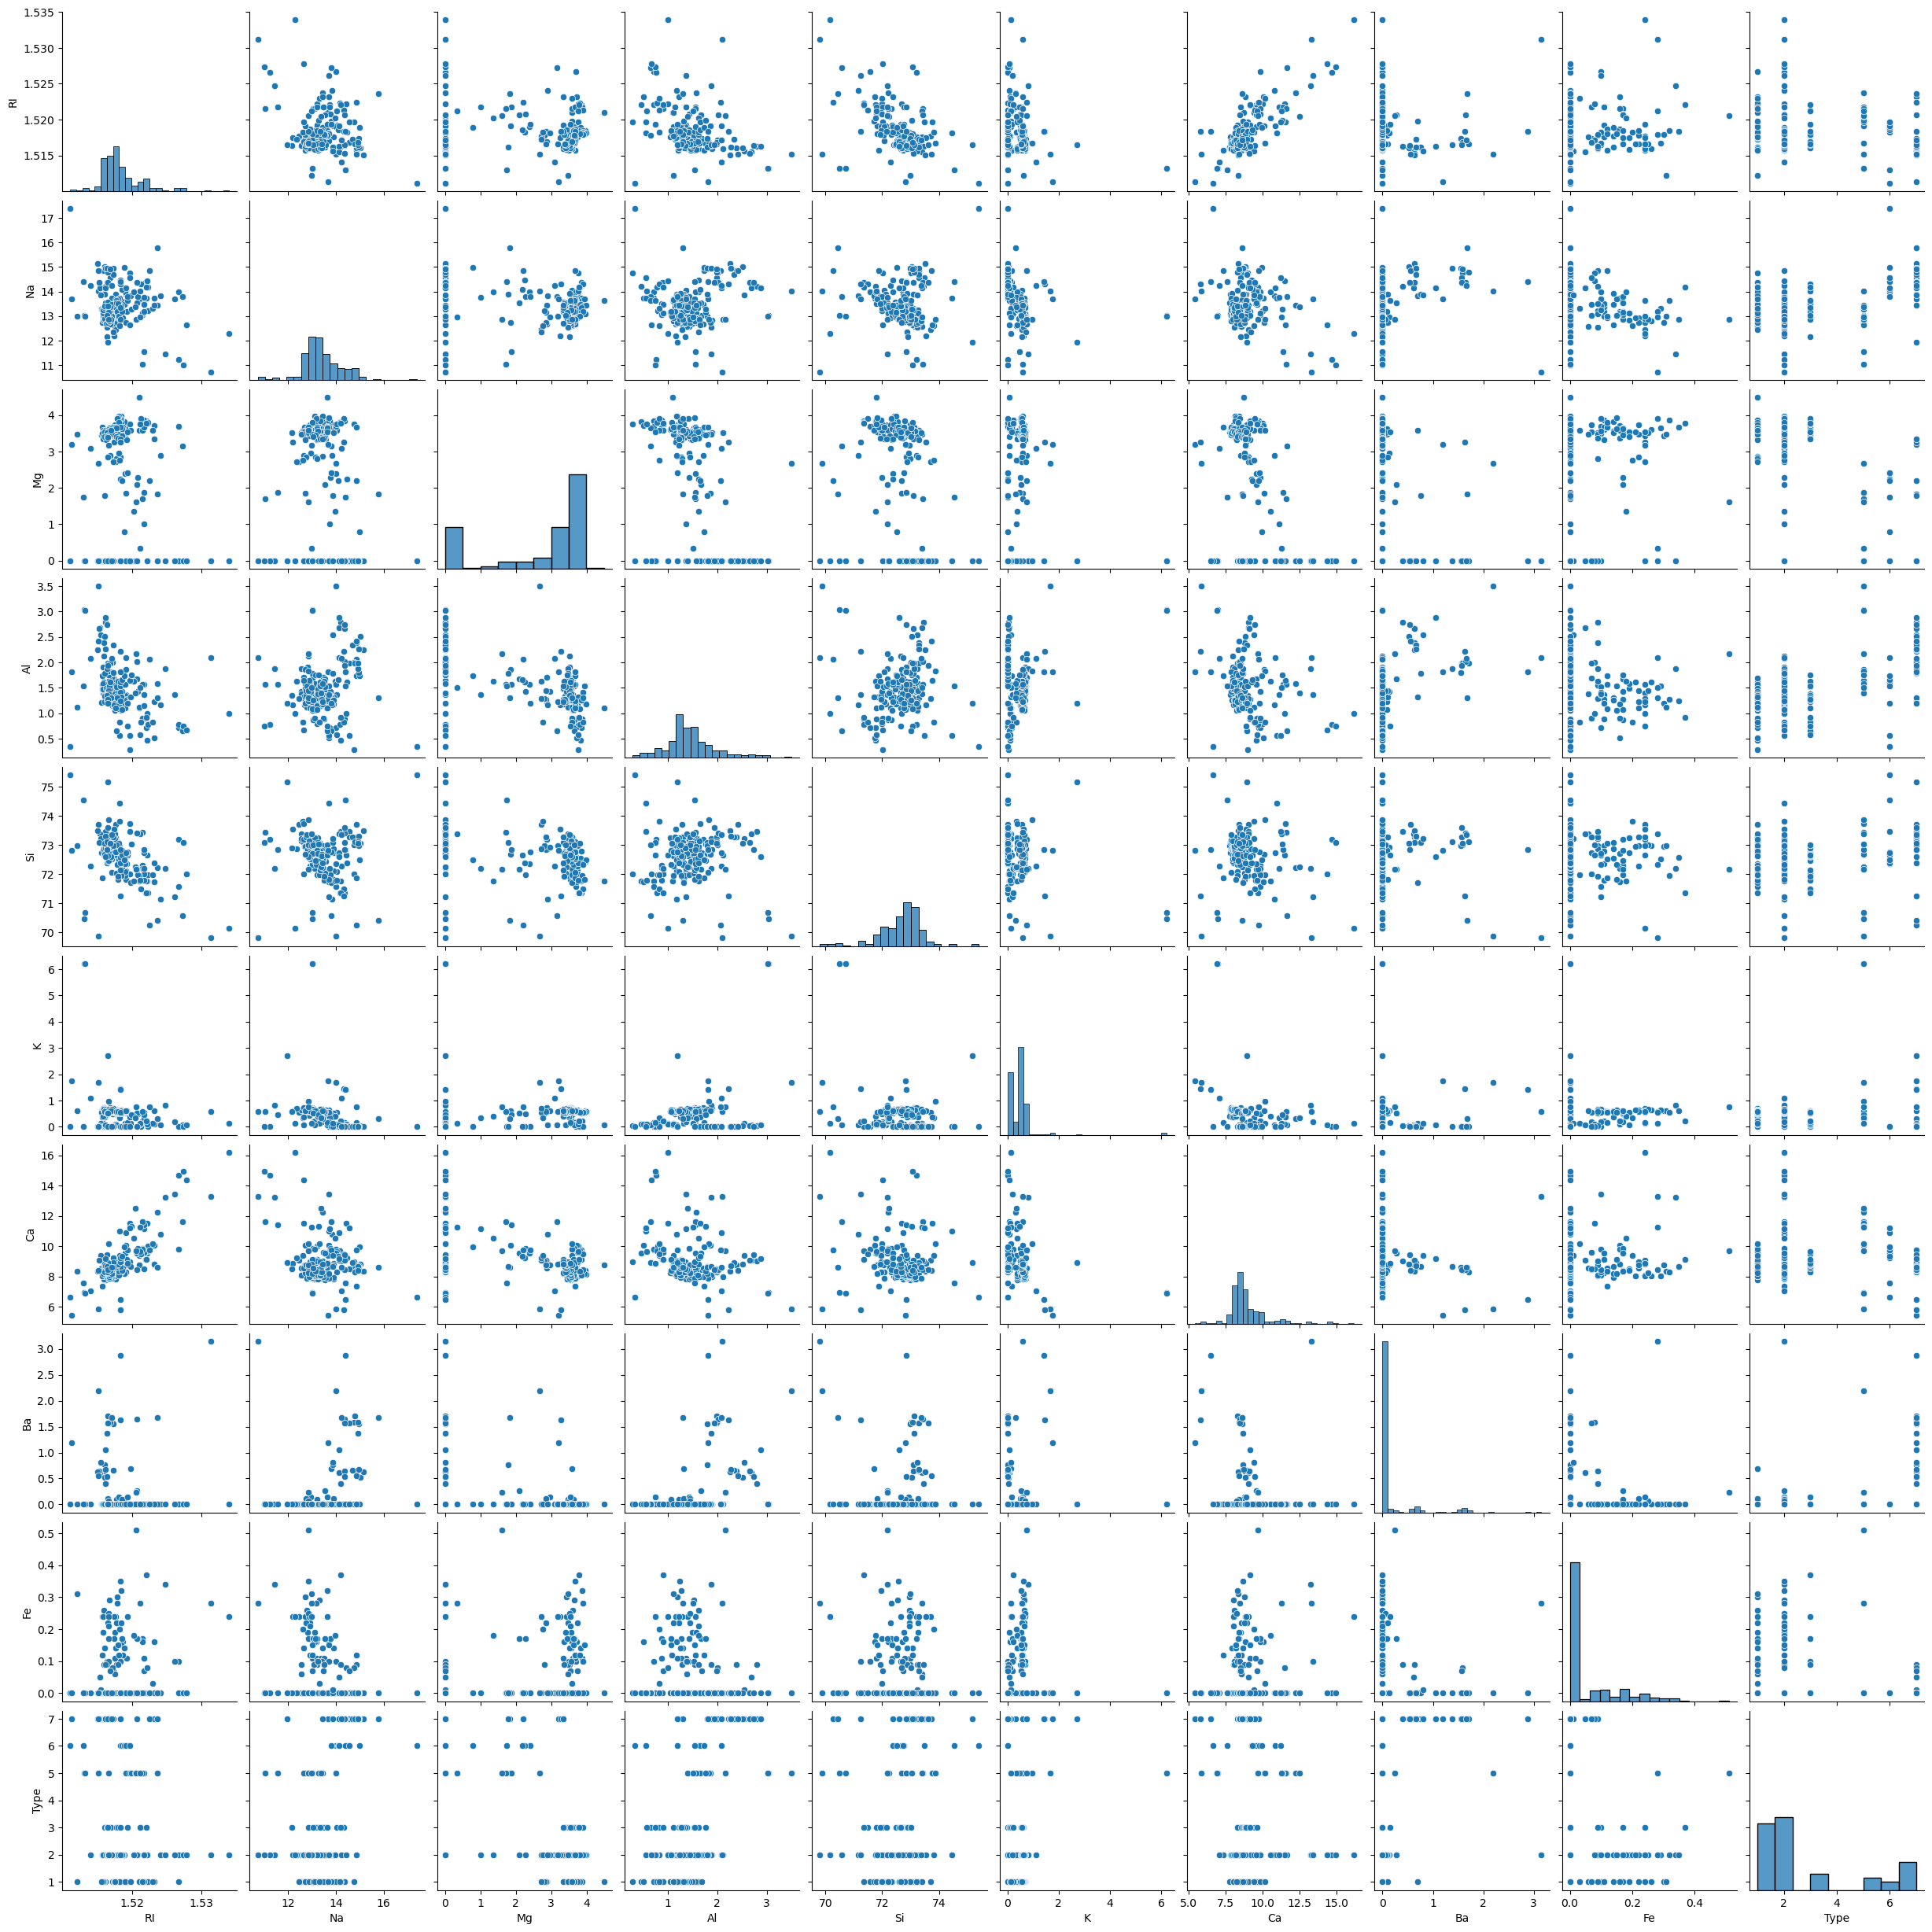

In [23]:
sns.pairplot(df)
plt.show()

### Correlation matrix

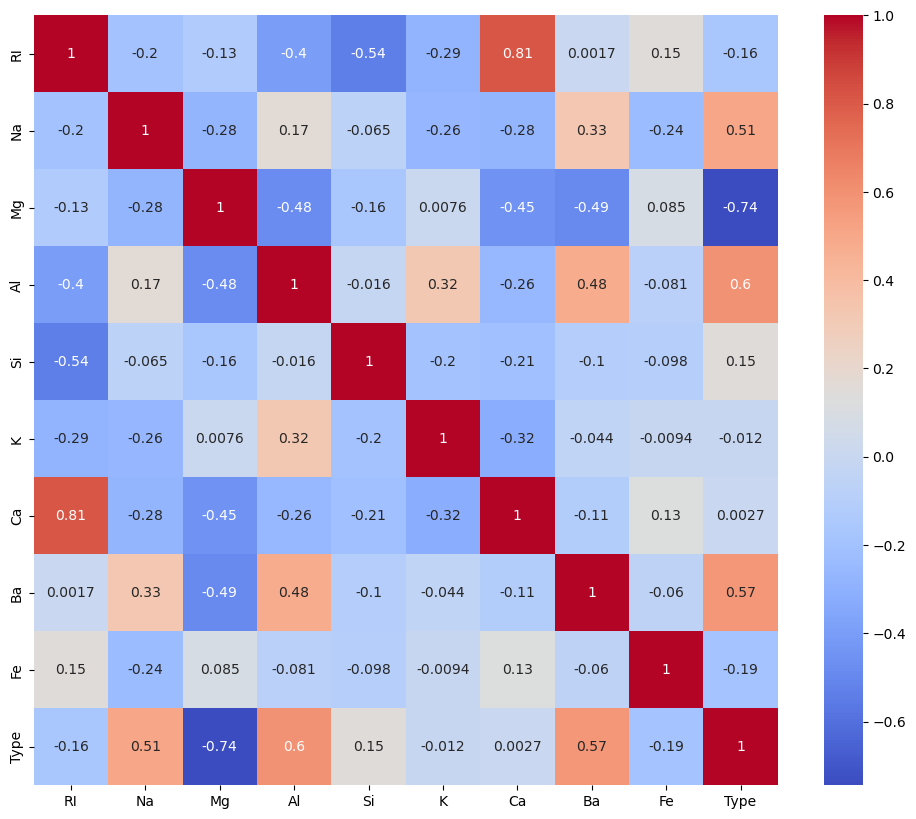

In [24]:
plt.figure(figsize = (12,10))
sns.heatmap(df.corr(numeric_only = True),
            annot = True,
            cmap ='coolwarm')
plt.show()

In [25]:
df['Type'].value_counts()

Type
2    76
1    69
7    29
3    17
5    13
6     9
Name: count, dtype: int64

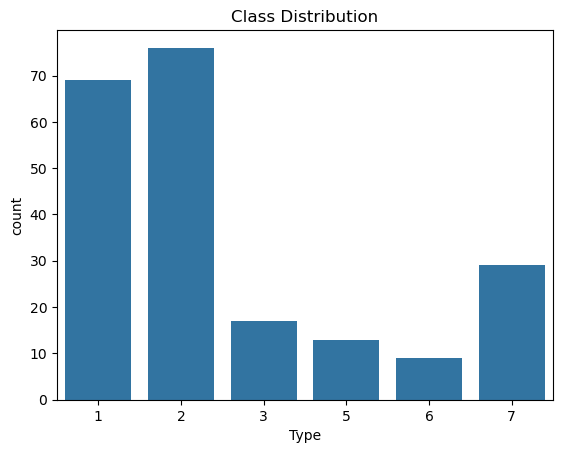

In [27]:
sns.countplot(x = df['Type'])
plt.title("Class Distribution")
plt.show()

In [28]:
X = df.drop("Type", axis = 1)
y = df['Type']

In [29]:
print(X.shape)

(213, 9)


In [30]:
print(y.shape)

(213,)


In [32]:
X = pd.get_dummies(X, drop_first = True)

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [38]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_resampled.value_counts())

Before SMOTE:
Type
2    61
1    55
7    23
3    14
5    10
6     7
Name: count, dtype: int64

After SMOTE:
Type
7    61
1    61
2    61
3    61
5    61
6    61
Name: count, dtype: int64


In [39]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

### Random Forest Model

In [40]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train_resampled)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
y_pred = rf_model.predict(X_test_scaled)

In [42]:
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy', accuracy)

Accuracy 0.7906976744186046


In [45]:
precision = precision_score(y_test, y_pred, average="weighted")
print("Precision: ", precision)

Precision:  0.805094130675526


In [51]:
recall = recall_score(y_test, y_pred, average = 'weighted')
print('Recall : ', recall)

Recall :  0.7906976744186046


In [52]:
f1 = f1_score(y_test, y_pred, average="weighted")
print("F1 Score: ", f1)

F1 Score:  0.7941428258990408


In [53]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.79      0.79      0.79        14
           2       0.79      0.73      0.76        15
           3       0.50      0.67      0.57         3
           5       1.00      1.00      1.00         3
           6       0.67      1.00      0.80         2
           7       1.00      0.83      0.91         6

    accuracy                           0.79        43
   macro avg       0.79      0.84      0.80        43
weighted avg       0.81      0.79      0.79        43



### Confusion Matrix

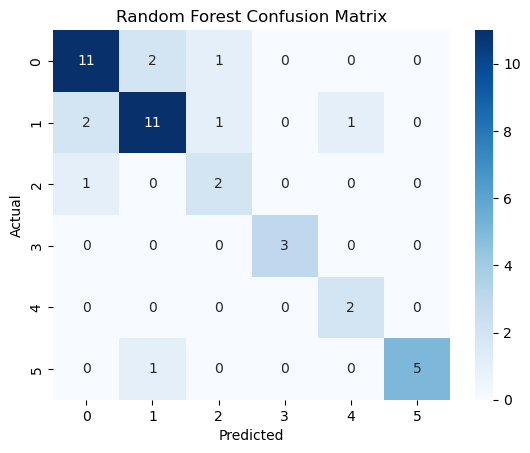

In [55]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

### Bagging

In [58]:
##bagging
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

bagging.fit(X_train, y_train)

bag_pred = bagging.predict(X_test)

print("Bagging Accuracy:",
      accuracy_score(y_test, bag_pred))

Bagging Accuracy: 0.7906976744186046


In [59]:
##boosting
boosting = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

boosting.fit(X_train, y_train)

boost_pred = boosting.predict(X_test)

print("Boosting Accuracy:",
      accuracy_score(y_test, boost_pred))

Boosting Accuracy: 0.3953488372093023


#### 1.Explain Bagging and Boosting. How are they different?

##### Bagging (Bootstrap Aggregating) is an ensemble technique where multiple models are trained independently on different random subsets of the data. Their predictions are combined using voting or averaging. Bagging mainly reduces variance and helps prevent overfitting.

##### Boosting is an ensemble technique where models are trained sequentially. Each new model focuses on correcting the mistakes made by previous models. Boosting mainly reduces bias and improves predictive performance.

##### Difference Between Bagging and Boosting Bagging Boosting Models are trained independently Models are trained sequentially Reduces variance Reduces bias Less sensitive to noise More sensitive to noise Example: Random Forest Example: AdaBoost

#### 2.Explain how to handle imbalance in the data.

##### Imbalanced data occurs when one class has significantly more samples than another class.

##### Common techniques to handle imbalance are:
##### Oversampling Increase minority class samples. Example: SMOTE. Undersampling Reduce majority class samples.

##### Class Weighting
##### Assign higher weight to minority classes. Example: RandomForestClassifier(class_weight='balanced') Ensemble Methods Use techniques such as Random Forest and Boosting which handle imbalance better.

##### These techniques improve model performance and prevent bias toward majority classes.